In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import enrichmap as em
import numpy as np

In [4]:
sc.settings.set_figure_params(frameon=False)
sc.settings._vector_friendly = False

In [5]:
adata = sc.read_h5ad("data/adata_with_signatures_and_hotspots.h5ad")

In [6]:
adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

In [7]:
gene_sets = {
    "CCL signalling": ["CCL5", "SDC4"],
    "PTN signalling": ["PTN", "PTPRB"],
}

In [8]:
em.tl.score(adata, gene_set=gene_sets, batch_key="batch", n_neighbors=24)

Scoring signatures: 100%|██████████| 2/2 [00:20<00:00, 10.31s/it]


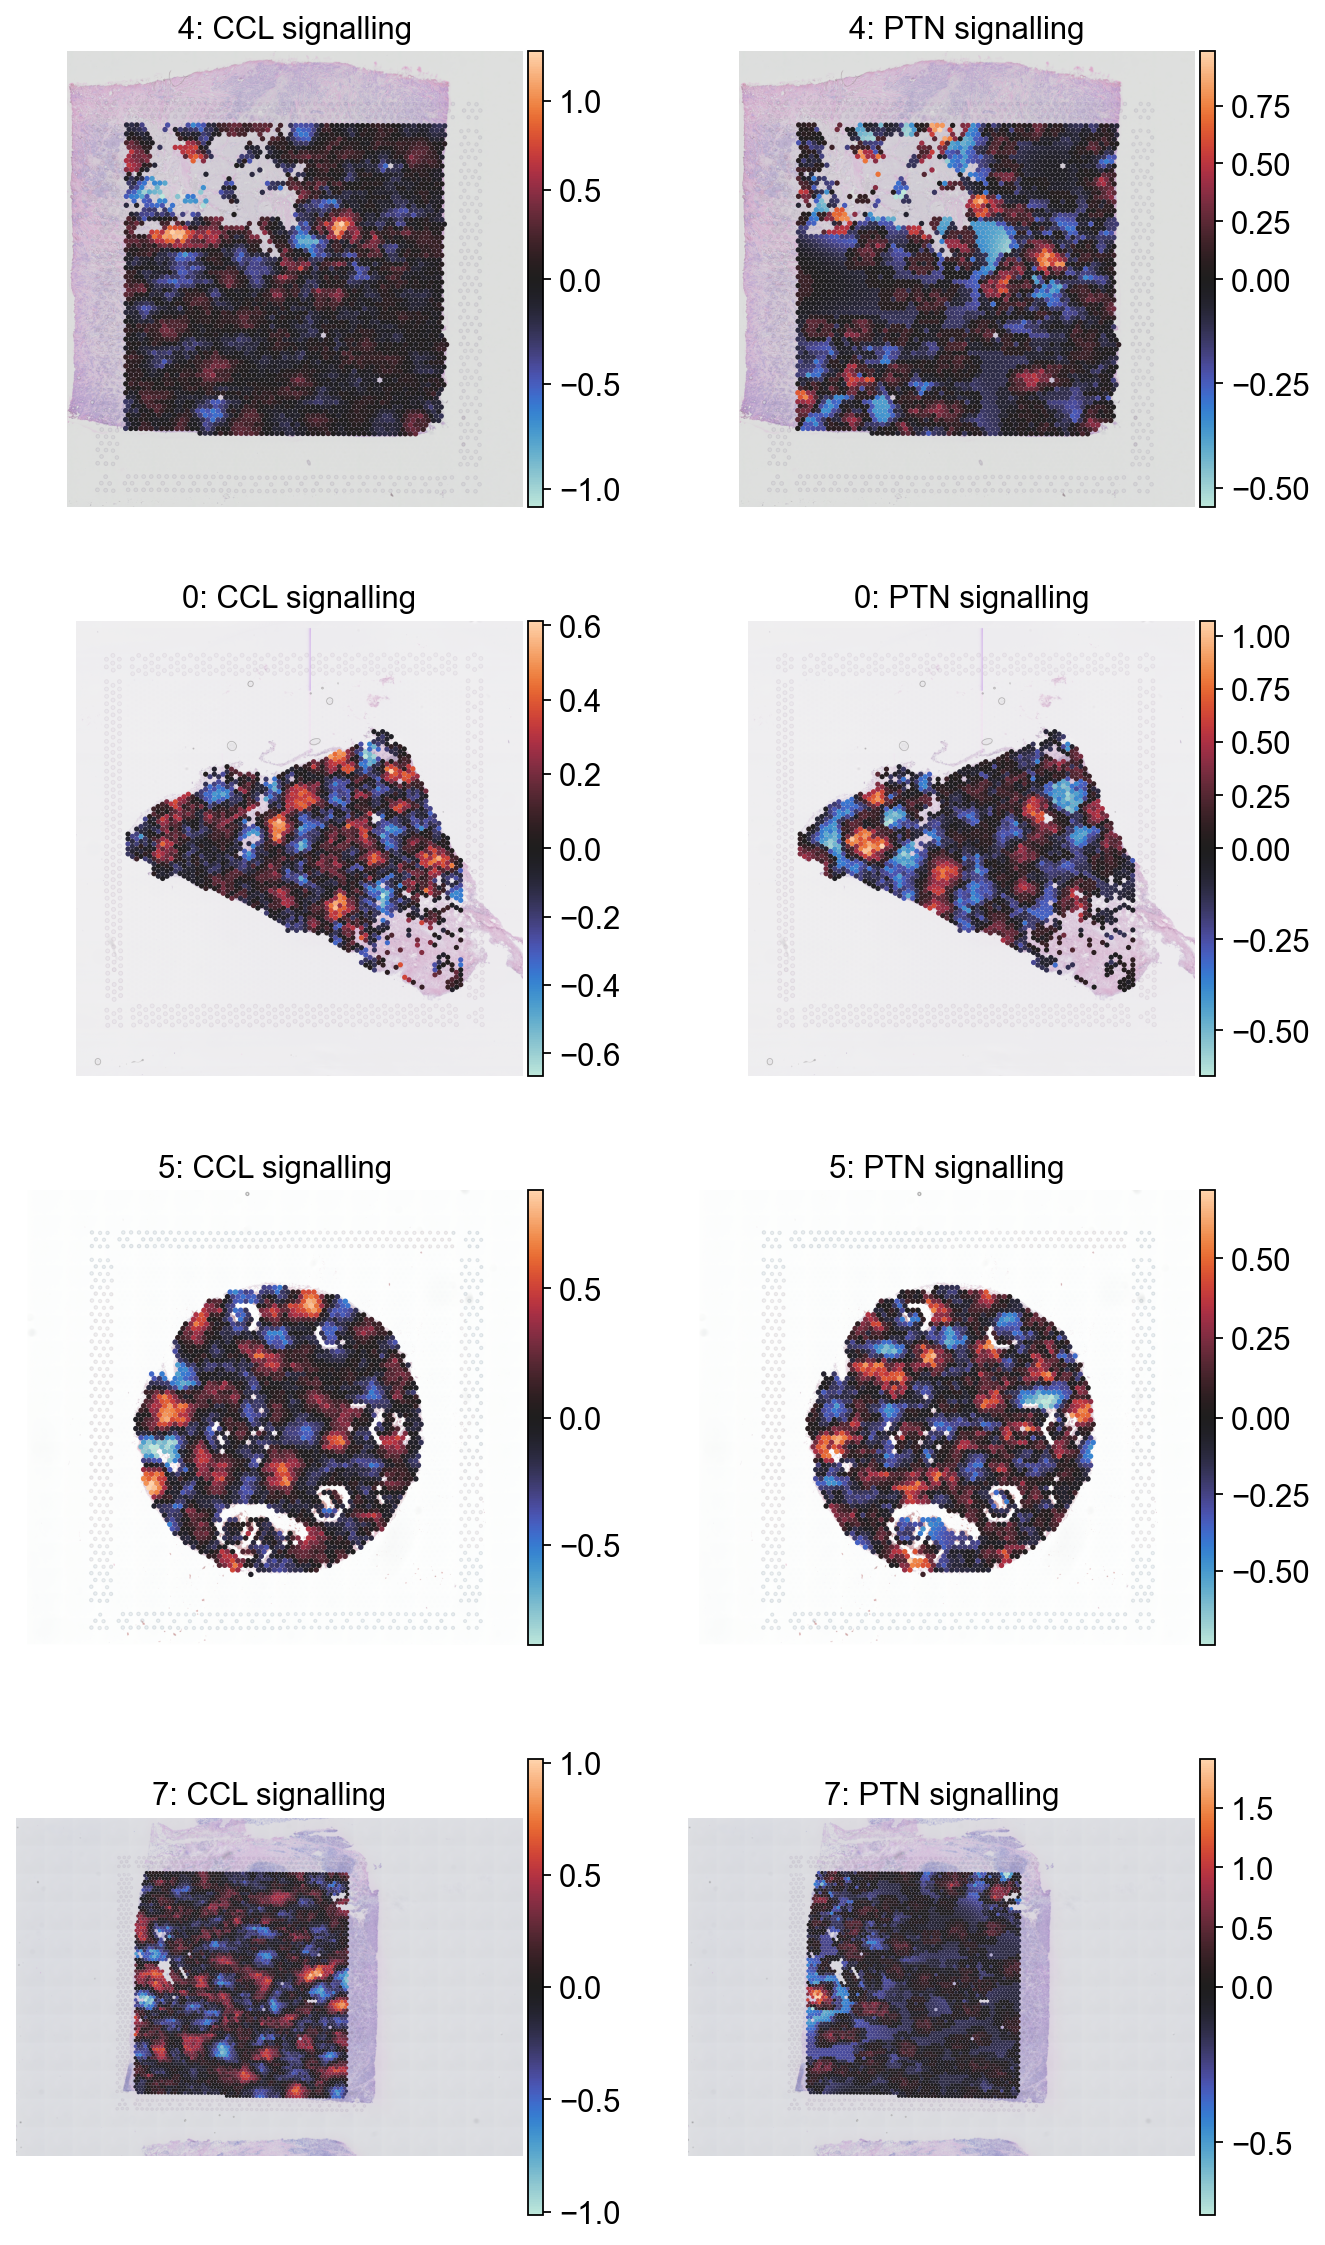

In [9]:
em.pl.spatial_enrichmap(
    adata,
    score_key=[key + "_score" for key in gene_sets.keys()],
    size=1.6,
    library_key="batch",
    library_id=["4", "0", "5", "7"],
    cmap="icefire",
    save="enrichmap_spatial_signalling.pdf"
)

In [38]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("quiescence", ["#2FBF71", "#6A5ACD"], N=256)

In [12]:
import pickle

with open("gene_sets.pkl", "rb") as f:
    gene_sets = pickle.load(f)

In [13]:
em.tl.score(adata, gene_sets, batch_key="batch")

Scoring signatures: 100%|██████████| 2/2 [01:34<00:00, 47.32s/it]


In [14]:
adata.obs["G0_score"] = adata.obs["upregulated_score"] - adata.obs["downregulated_score"]

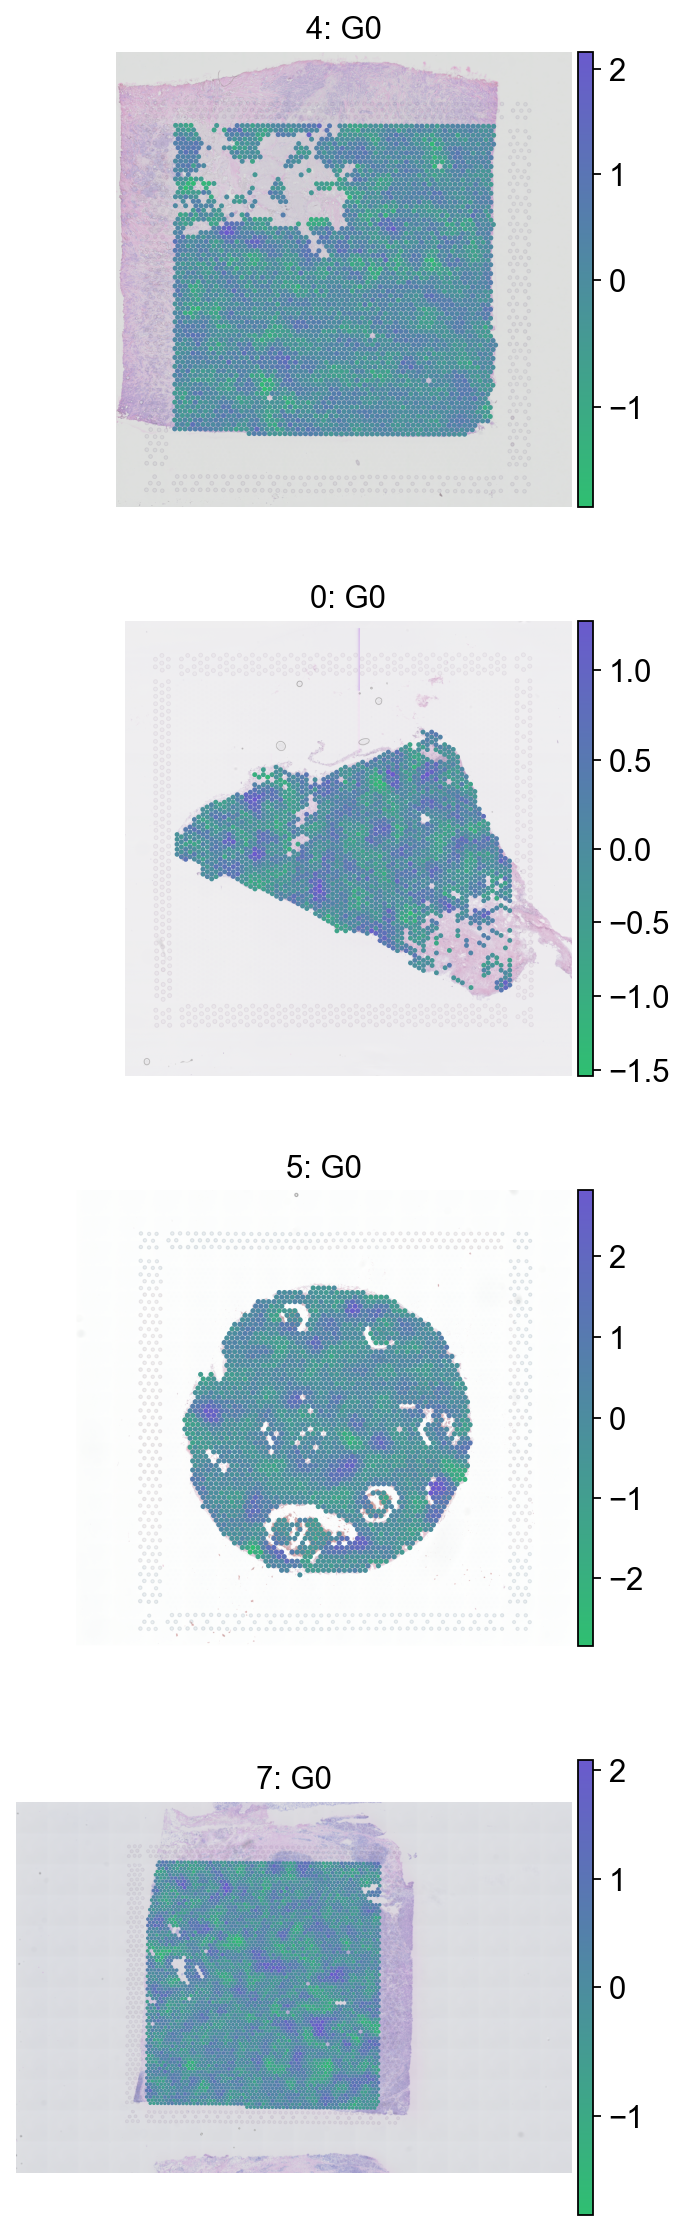

In [40]:
em.pl.spatial_enrichmap(
    adata,
    score_key=["G0_score"],
    size=1.5,
    library_key="batch",
    library_id=["4", "0", "5", "7"],
    cmap=cmap,
    save="enrichmap_G0_score.pdf",
)